In [1]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# importing df from github
url = 'https://raw.githubusercontent.com/MohammadErfanRashidi/Customer-Churn/refs/heads/main/data/Customer-Churn_Cleaned.csv'
df = pd.read_csv(url)
green = '#2ecc71'   # no churn
red = '#e74c3c'     # yes churn

In [9]:
# head
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


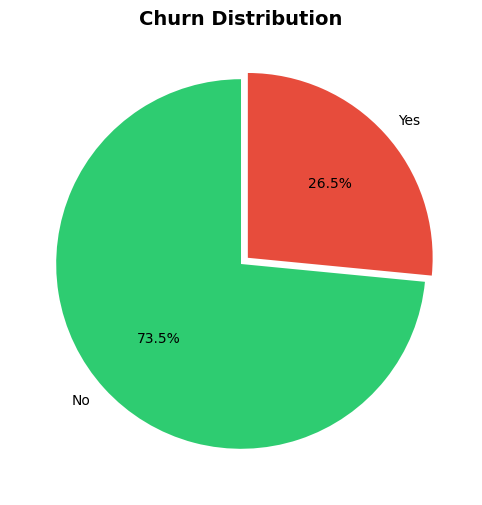

In [10]:
# shows overall percentage of customers who churned vs stayed
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=[green, red], startangle=90, explode=(0, 0.05))
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.show()

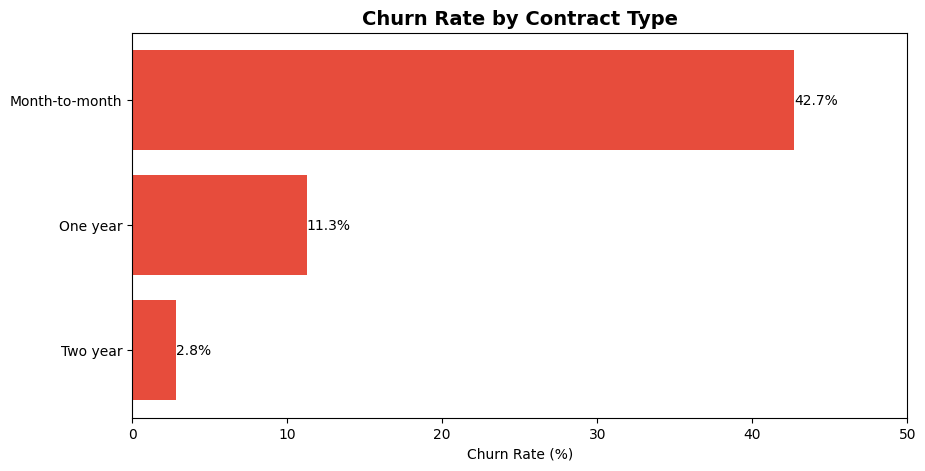

In [11]:
# month-to-month contracts have significantly higher churn
contract_churn = df.groupby('Contract')['Churn'].value_counts().unstack()
contract_churn_pct = (contract_churn['Yes'] / contract_churn.sum(axis=1) * 100).sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(contract_churn_pct.index, contract_churn_pct.values, color=red)
plt.bar_label(bars, fmt='%.1f%%')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.xlim(0, 50)
plt.show()

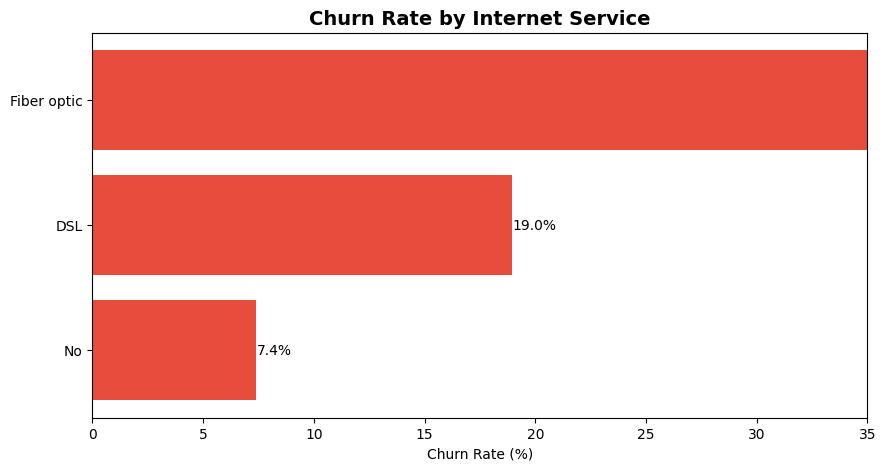

In [12]:
# fiber optic customers churn more than dsl users
internet_churn = df.groupby('InternetService')['Churn'].value_counts().unstack()
internet_churn_pct = (internet_churn['Yes'] / internet_churn.sum(axis=1) * 100).sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(internet_churn_pct.index, internet_churn_pct.values, color=red)
plt.bar_label(bars, fmt='%.1f%%')
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.xlim(0, 35)
plt.show()

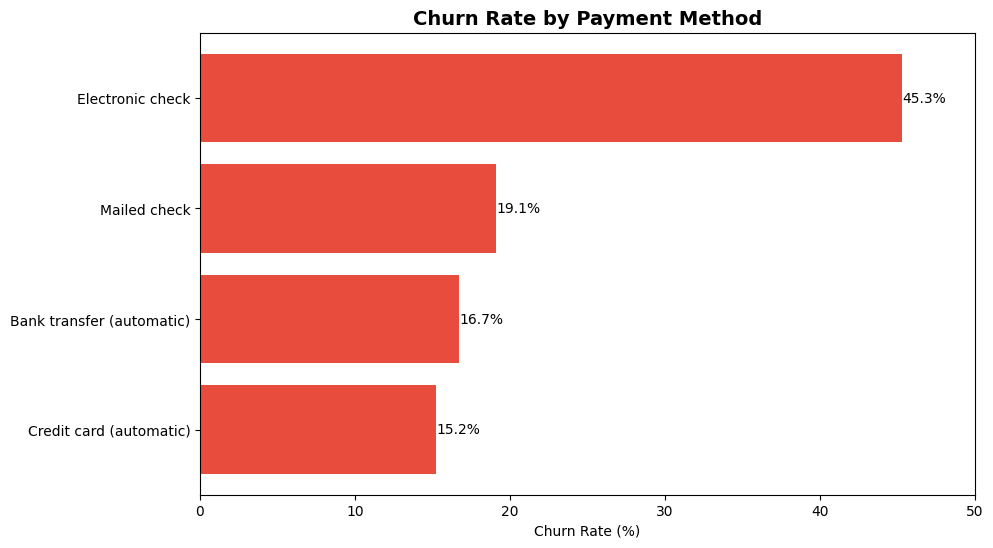

In [13]:
# electronic check users have highest churn rate
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts().unstack()
payment_churn_pct = (payment_churn['Yes'] / payment_churn.sum(axis=1) * 100).sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(payment_churn_pct.index, payment_churn_pct.values, color=red)
plt.bar_label(bars, fmt='%.1f%%')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.xlim(0, 50)
plt.show()

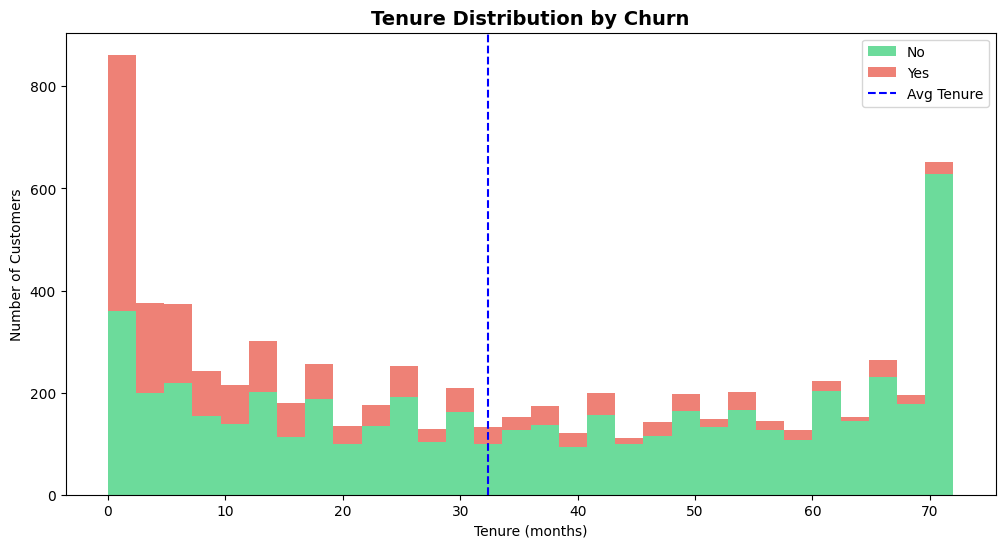

In [14]:
# most churned customers left within first 12 months
churned = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

plt.figure(figsize=(12, 6))
plt.hist([not_churned, churned], bins=30, stacked=True, 
         color=[green, red], label=['No', 'Yes'], alpha=0.7)
plt.title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.axvline(x=df['tenure'].mean(), color='blue', linestyle='--', label='Avg Tenure')
plt.legend()
plt.show()

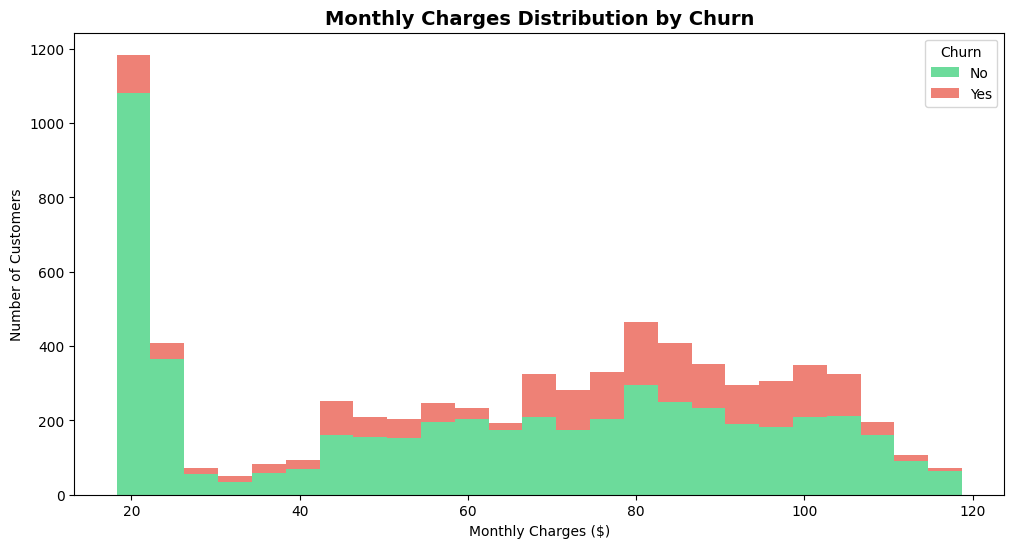

In [15]:
# higher monthly charges correlate with increased churn
churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned_charges = df[df['Churn'] == 'No']['MonthlyCharges']

plt.figure(figsize=(12, 6))
plt.hist([not_churned_charges, churned_charges], bins=25, stacked=True,
         color=[green, red], label=['No', 'Yes'], alpha=0.7)
plt.title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

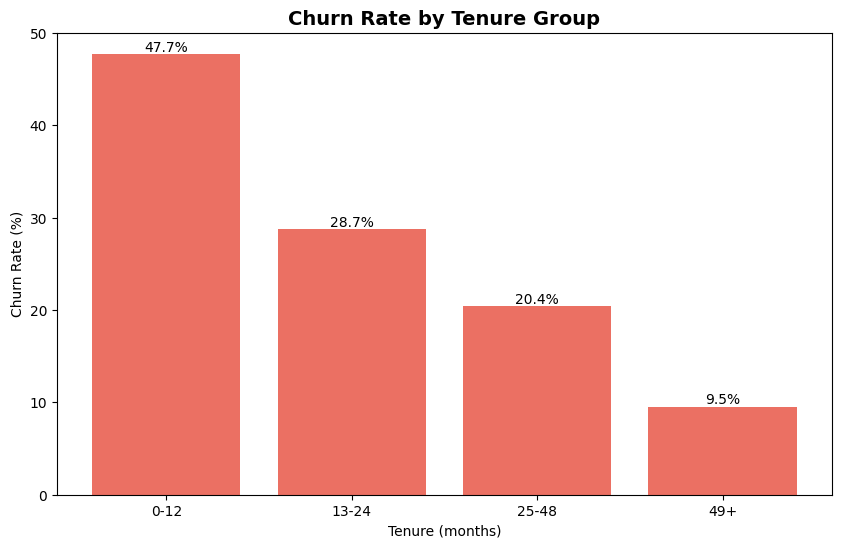

In [16]:
# churn rate drops significantly after first year
bins = [0, 12, 24, 48, 100]
labels = ['0-12', '13-24', '25-48', '49+']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

tenure_churn = df.groupby('TenureGroup')['Churn'].value_counts().unstack()
tenure_churn_pct = (tenure_churn['Yes'] / tenure_churn.sum(axis=1) * 100)

plt.figure(figsize=(10, 6))
x = range(len(tenure_churn_pct))
bars = plt.bar(x, tenure_churn_pct.values, color=red, alpha=0.8)
plt.bar_label(bars, fmt='%.1f%%')
plt.xticks(x, tenure_churn_pct.index)
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)
plt.show()

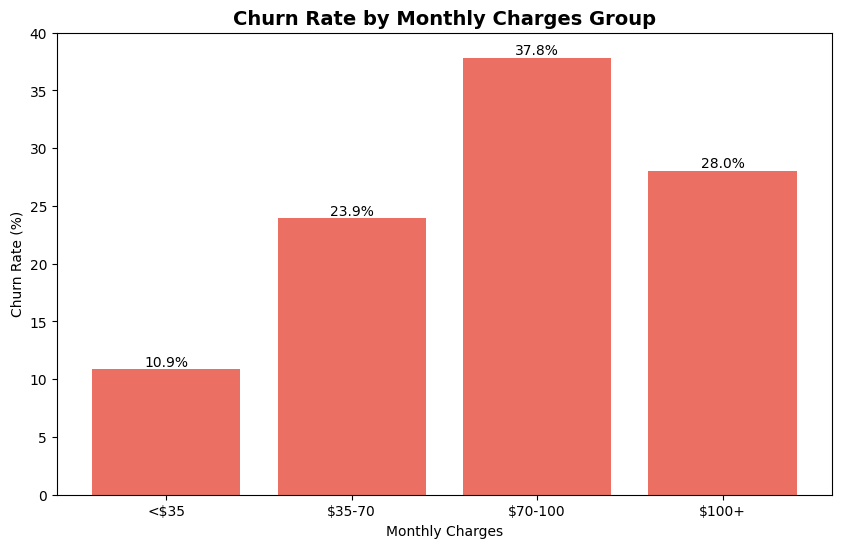

In [17]:
# customers paying over $100/month have highest churn risk
bins = [0, 35, 70, 100, 150]
labels = ['<$35', '$35-70', '$70-100', '$100+']
df['ChargeGroup'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels)

charge_churn = df.groupby('ChargeGroup')['Churn'].value_counts().unstack()
charge_churn_pct = (charge_churn['Yes'] / charge_churn.sum(axis=1) * 100)

plt.figure(figsize=(10, 6))
x = range(len(charge_churn_pct))
bars = plt.bar(x, charge_churn_pct.values, color=red, alpha=0.8)
plt.bar_label(bars, fmt='%.1f%%')
plt.xticks(x, charge_churn_pct.index)
plt.title('Churn Rate by Monthly Charges Group', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 40)
plt.show()

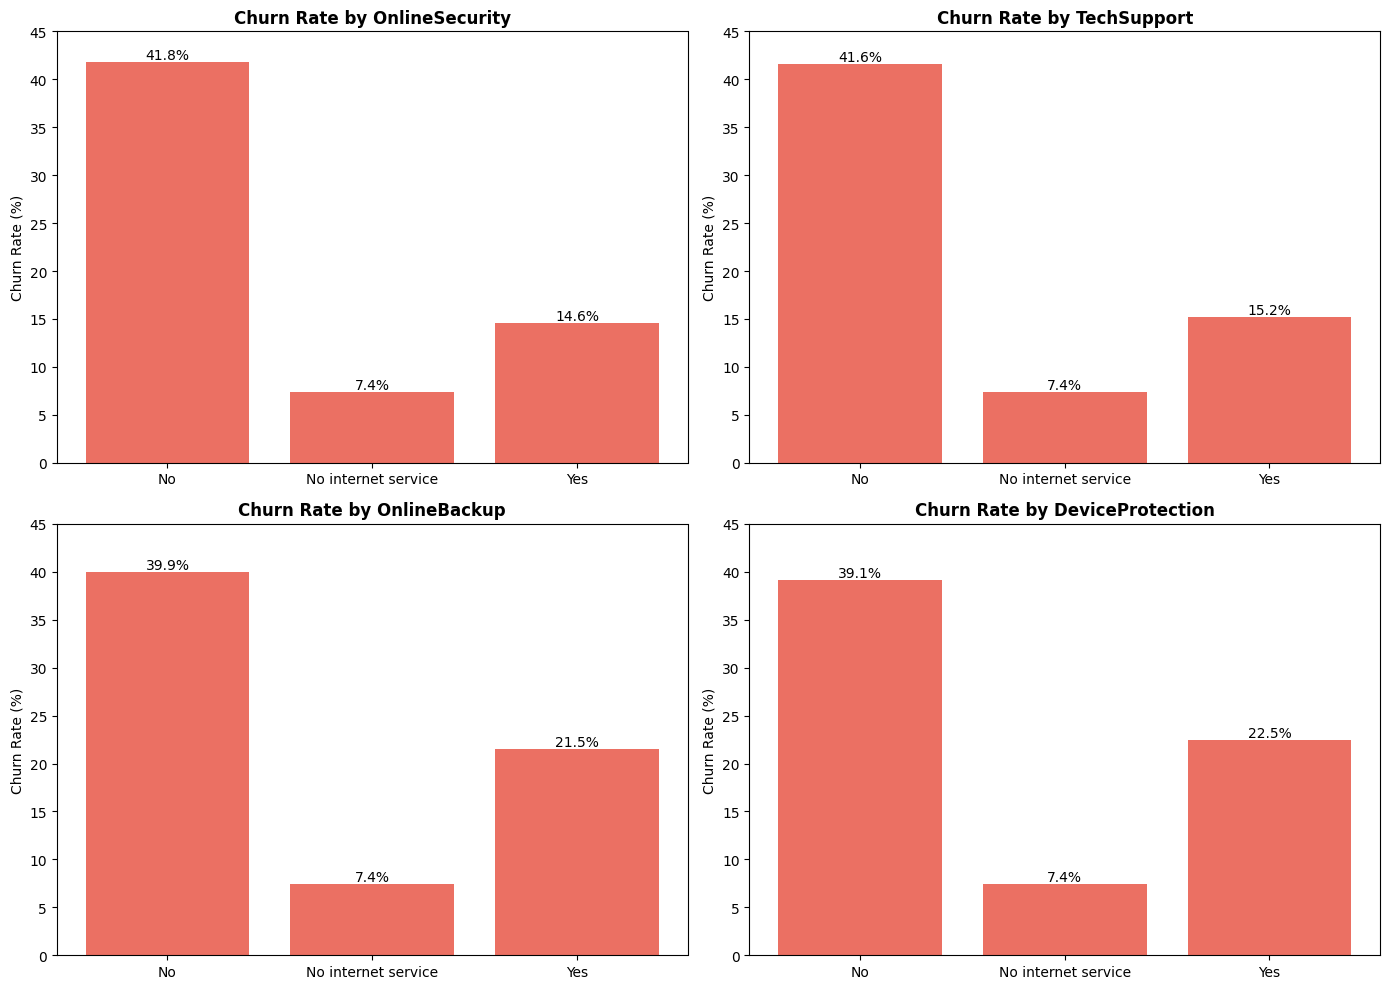

In [18]:
# lack of security and support services doubles churn rate
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, service in enumerate(services):
    service_churn = df.groupby(service)['Churn'].value_counts().unstack()
    service_churn_pct = (service_churn['Yes'] / service_churn.sum(axis=1) * 100)
    
    x = range(len(service_churn_pct))
    bars = axes[i].bar(x, service_churn_pct.values, color=red, alpha=0.8)
    axes[i].bar_label(bars, fmt='%.1f%%')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(service_churn_pct.index, rotation=0)
    axes[i].set_title(f'Churn Rate by {service}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 45)

plt.tight_layout()
plt.show()

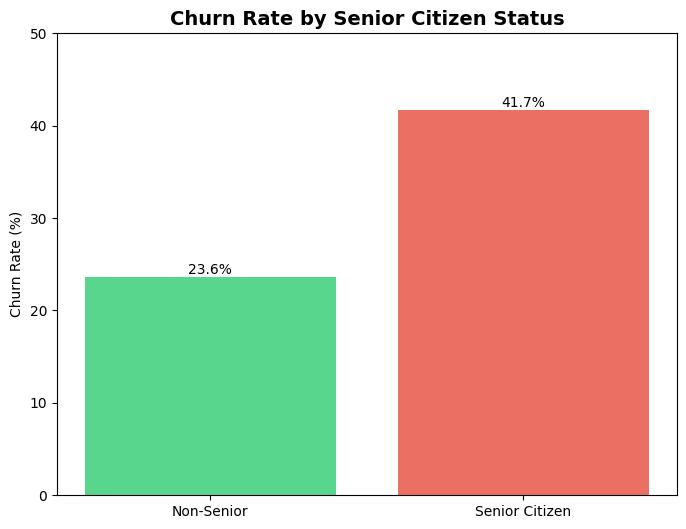

In [19]:
# senior citizens have slightly higher churn rate
senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts().unstack()
senior_churn_pct = (senior_churn['Yes'] / senior_churn.sum(axis=1) * 100)

plt.figure(figsize=(8, 6))
x = range(len(senior_churn_pct))
bars = plt.bar(x, senior_churn_pct.values, color=[green, red], alpha=0.8)
plt.bar_label(bars, fmt='%.1f%%')
plt.xticks(x, ['Non-Senior', 'Senior Citizen'])
plt.title('Churn Rate by Senior Citizen Status', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)
plt.show()

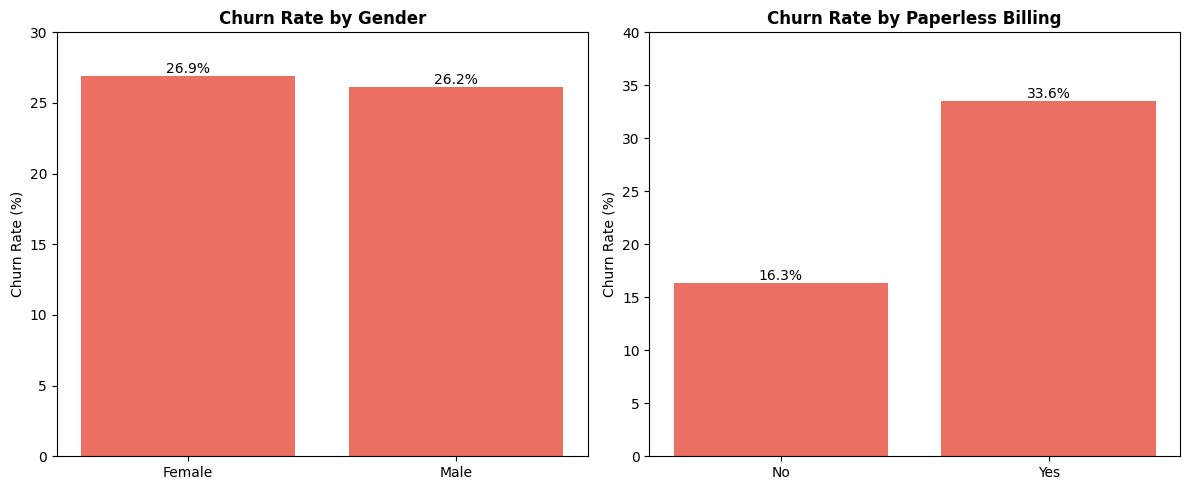

In [21]:
# gender alone doesn't show major difference in churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# gender
gender_churn = df.groupby('gender')['Churn'].value_counts().unstack()
gender_churn_pct = (gender_churn['Yes'] / gender_churn.sum(axis=1) * 100)
x = range(len(gender_churn_pct))
bars = axes[0].bar(x, gender_churn_pct.values, color=red, alpha=0.8)
axes[0].bar_label(bars, fmt='%.1f%%')
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_churn_pct.index)
axes[0].set_title('Churn Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 30)

# paperless billing
paperless_churn = df.groupby('PaperlessBilling')['Churn'].value_counts().unstack()
paperless_churn_pct = (paperless_churn['Yes'] / paperless_churn.sum(axis=1) * 100)
x = range(len(paperless_churn_pct))
bars = axes[1].bar(x, paperless_churn_pct.values, color=red, alpha=0.8)
axes[1].bar_label(bars, fmt='%.1f%%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(paperless_churn_pct.index)
axes[1].set_title('Churn Rate by Paperless Billing', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 40)

plt.tight_layout()
plt.show()